In [2]:
import pandas as pd
import numpy as np
from contextlib import contextmanager
from datetime import datetime
from pathlib import Path
from typing import Optional
import matplotlib.pyplot as plt
import polars as pl
import psutil
import seaborn as sns

# 1. Coinmetrics

In [3]:
# read data
df = pd.read_csv("../data/Coin Metrics/coinmetrics_btc.csv")
df["time"] = pd.to_datetime(df["time"])
df.head()

,time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,...,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
0,2009-01-03,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN
1,2009-01-04,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN
2,2009-01-05,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN
3,2009-01-06,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN
4,2009-01-07,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN


In [4]:
# test the commit
start = "2018-01-01"
end = "2025-12-31"
df = df[(df["time"] >= start) & (df["time"] <= end)].copy()
# sort and set the index
df = df.sort_values("time").set_index("time")

In [5]:
# check missing date
all_days = pd.date_range(start, end, freq="D")
missing_days = all_days.difference(df.index)
len(missing_days)

0

In [6]:
# missing rate
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("missing rate Top 20（%）：")
print(missing_pct.head(20))

key_cols = [
    "PriceUSD", "CapMrktCurUSD", "HashRate", "TxCnt",
    "CapMVRVCur", "SplyCur", "FeeTotNtv",
    "FlowInExUSD", "FlowOutExUSD",
    "volume_reported_spot_usd_1d"
]
key_cols = [c for c in key_cols if c in df.columns]

print("\nkey row describe：")
print(df[key_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

missing rate Top 20（%）：
ReferenceRate             100.000000
ReferenceRateEUR          100.000000
ReferenceRateETH          100.000000
ReferenceRateUSD          100.000000
CapMrktEstUSD              18.377823
AdrBalCnt                   0.000000
AdrActCnt                   0.000000
CapMrktCurUSD               0.000000
FeeTotNtv                   0.000000
FlowInExNtv                 0.000000
FlowInExUSD                 0.000000
AssetEODCompletionTime      0.000000
BlkCnt                      0.000000
CapMVRVCur                  0.000000
AssetCompletionTime         0.000000
IssTotNtv                   0.000000
HashRate                    0.000000
FlowOutExUSD                0.000000
FlowOutExNtv                0.000000
ROI1yr                      0.000000
dtype: float64

key row describe：
                              count          mean           std           min  \
PriceUSD                     2922.0  3.726383e+04  3.222417e+04  3.185074e+03   
CapMrktCurUSD                2922.0  7.2

In [7]:
# 6) create metrics

px = df["PriceUSD"]

df["ret_1d"] = px.pct_change()
df["logret_1d"] = np.log(px).diff()

# annualized vol
df["vol_30d"] = df["logret_1d"].rolling(30).std() * np.sqrt(365)

# 200 DMA
df["ma_200"] = px.rolling(200).mean()
df["price_vs_ma200"] = px / df["ma_200"] - 1

# Drawdown
rolling_max = px.cummax()
df["drawdown"] = px / rolling_max - 1


In [8]:
df.columns

Index(['AdrActCnt', 'AdrBalCnt', 'AssetCompletionTime',
       'AssetEODCompletionTime', 'BlkCnt', 'CapMVRVCur', 'CapMrktCurUSD',
       'CapMrktEstUSD', 'FeeTotNtv', 'FlowInExNtv', 'FlowInExUSD',
       'FlowOutExNtv', 'FlowOutExUSD', 'HashRate', 'IssTotNtv', 'IssTotUSD',
       'PriceBTC', 'PriceUSD', 'ROI1yr', 'ROI30d', 'ReferenceRate',
       'ReferenceRateETH', 'ReferenceRateEUR', 'ReferenceRateUSD', 'SplyCur',
       'SplyExNtv', 'SplyExUSD', 'SplyExpFut10yr', 'TxCnt', 'TxTfrCnt',
       'volume_reported_spot_usd_1d', 'ret_1d', 'logret_1d', 'vol_30d',
       'ma_200', 'price_vs_ma200', 'drawdown'],
      dtype='object')

In [9]:
df.head()

,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,...,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d,ret_1d,logret_1d,vol_30d,ma_200,price_vs_ma200,drawdown
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01,972783.0,26829117.0,1.614337e+09,1.614337e+09,156.0,2.694235,2.258877e+11,NaN,477.225170,36000.622080,...,2.027413e+07,241625.0,677625.0,4.860752e+09,NaN,NaN,NaN,NaN,NaN,0.0
2018-01-02,1142721.0,26909375.0,1.614337e+09,1.614337e+09,171.0,2.925443,2.475552e+11,NaN,649.878138,65831.310897,...,2.027467e+07,343664.0,960051.0,8.485368e+09,0.095782,0.091468,NaN,NaN,NaN,0.0
2018-01-03,1130917.0,27133378.0,1.614337e+09,1.614337e+09,157.0,2.960267,2.518793e+11,NaN,750.020447,56969.474964,...,2.027516e+07,396942.0,1049679.0,8.041486e+09,0.017348,0.017200,NaN,NaN,NaN,0.0
2018-01-04,1253986.0,27415056.0,1.614337e+09,1.614337e+09,168.0,2.944022,2.529181e+11,NaN,777.017867,77816.063305,...,2.027568e+07,424762.0,1191394.0,1.138178e+10,0.003998,0.003990,NaN,NaN,NaN,0.0
2018-01-05,1069525.0,27645350.0,1.614337e+09,1.614337e+09,143.0,3.261964,2.852872e+11,NaN,704.313737,72765.218396,...,2.027613e+07,339441.0,1002989.0,1.288165e+10,0.127863,0.120324,NaN,NaN,NaN,0.0


# 2. Coinmetrics EDA

In [10]:
metrics = ["PriceUSD", "CapMrktCurUSD", "HashRate"]
df[metrics].describe()

,PriceUSD,CapMrktCurUSD,HashRate
count,2922.000000,2.922000e+03,2.922000e+03
mean,37263.830507,7.219058e+11,3.164267e+08
std,32224.168884,6.439132e+11,3.023951e+08
min,3185.074044,5.549965e+10,1.372762e+07
25%,9447.177429,1.706965e+11,9.550205e+07
50%,27320.277455,5.303925e+11,1.780076e+08
75%,57402.905528,1.085182e+12,5.065075e+08
max,124824.453667,2.487865e+12,1.305500e+09


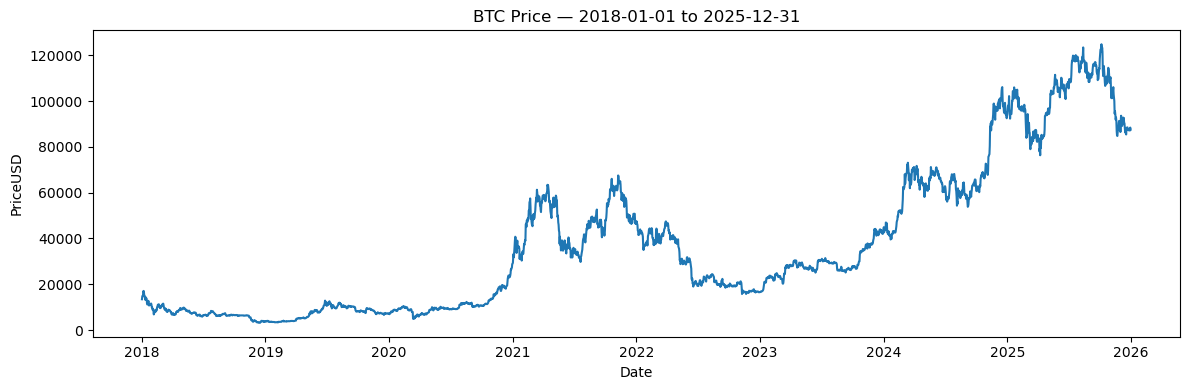

In [11]:
# Price Trend
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["PriceUSD"])
plt.title("BTC Price — 2018-01-01 to 2025-12-31")
plt.xlabel("Date")
plt.ylabel("PriceUSD")
plt.tight_layout()
plt.show()

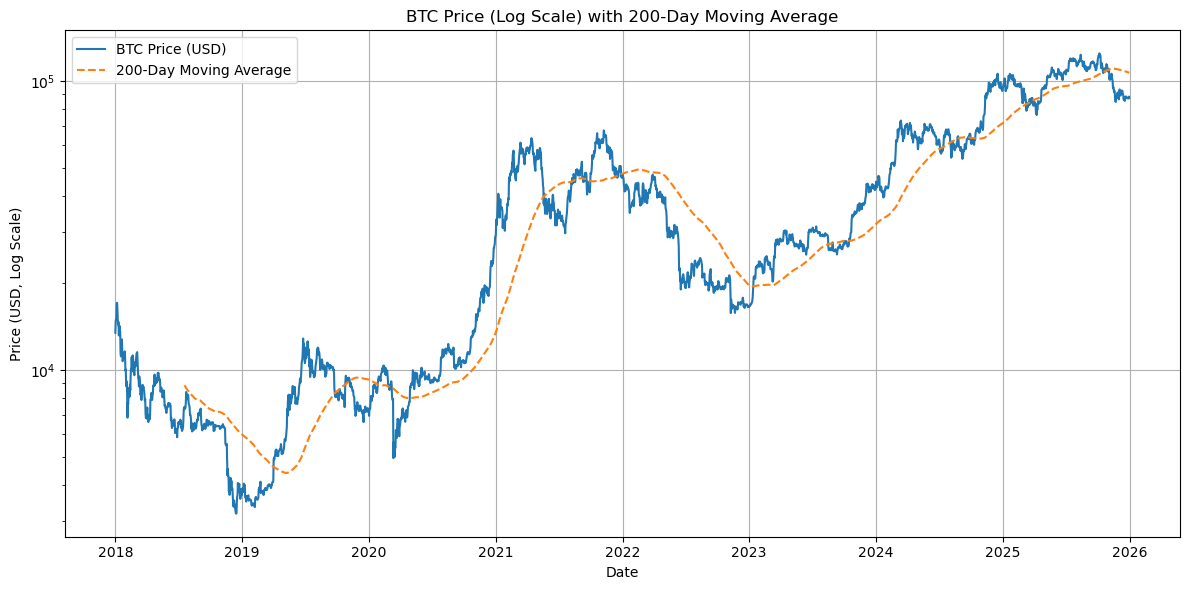

In [12]:
# BTC Price (Log Scale) with 200-Day Moving Average
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["PriceUSD"], label="BTC Price (USD)")
plt.plot(df.index, df["ma_200"], label="200-Day Moving Average", linestyle="--")

plt.yscale("log")

plt.title("BTC Price (Log Scale) with 200-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (USD, Log Scale)")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

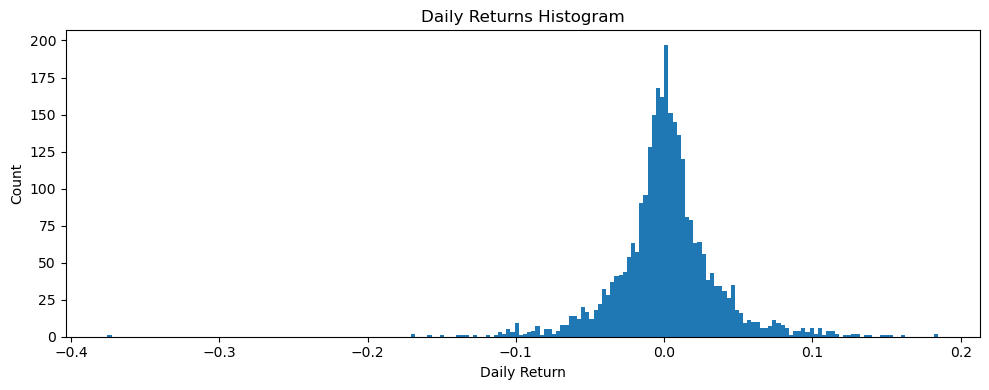

In [13]:
# Daily Profit Distribution
rets = df["ret_1d"].dropna()
plt.figure(figsize=(10, 4))
plt.hist(rets, bins=200)
plt.title("Daily Returns Histogram")
plt.xlabel("Daily Return")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [14]:
print("\nWorst 10 Days (ret_1d):")
print(rets.nsmallest(10))

print("\nBest 10 Days (ret_1d):")
print(rets.nlargest(10))


Worst 10 Days (ret_1d):
time
2020-03-12   -0.375350
2018-02-05   -0.169805
2022-06-13   -0.168244
2018-01-16   -0.158969
2022-11-09   -0.149165
2018-11-19   -0.137376
2019-06-27   -0.136329
2019-07-16   -0.133186
2021-01-21   -0.126495
2021-05-19   -0.120292
Name: ret_1d, dtype: float64

Best 10 Days (ret_1d):
time
2019-04-02    0.184926
2021-02-08    0.182522
2019-10-25    0.161286
2019-05-11    0.152202
2020-03-19    0.150406
2022-02-28    0.146409
2018-04-12    0.138168
2020-03-13    0.134772
2018-02-06    0.129804
2019-05-19    0.129398
Name: ret_1d, dtype: float64


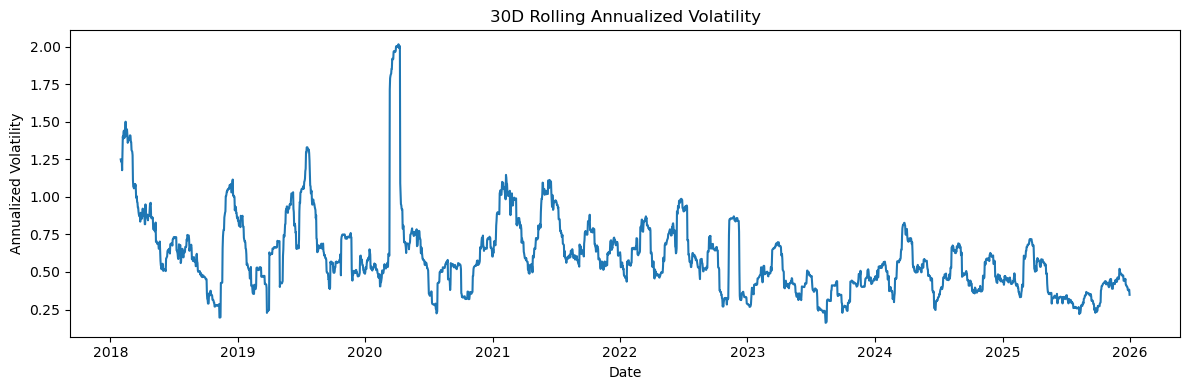

In [15]:
# 30D Rolling Annualized Volatility
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["vol_30d"])
plt.title("30D Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.tight_layout()
plt.show()

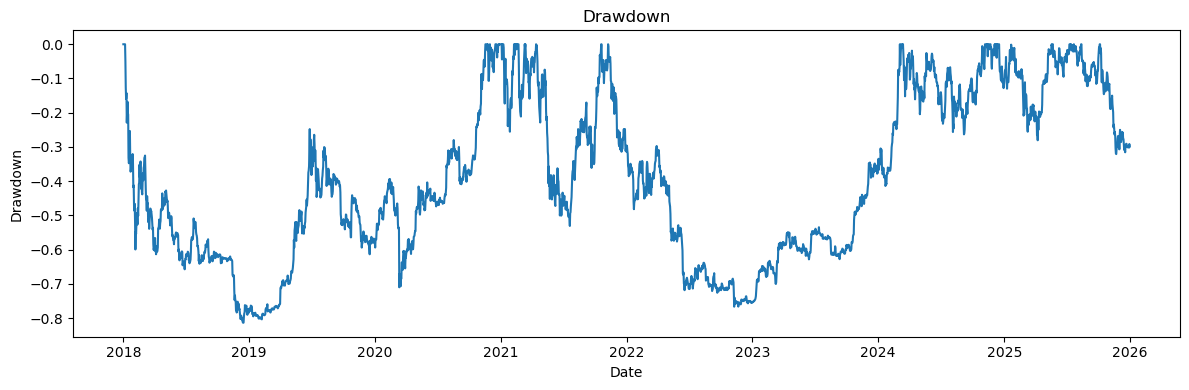

In [16]:
# Drawdown Plot
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["drawdown"])
plt.title("Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.tight_layout()
plt.show()

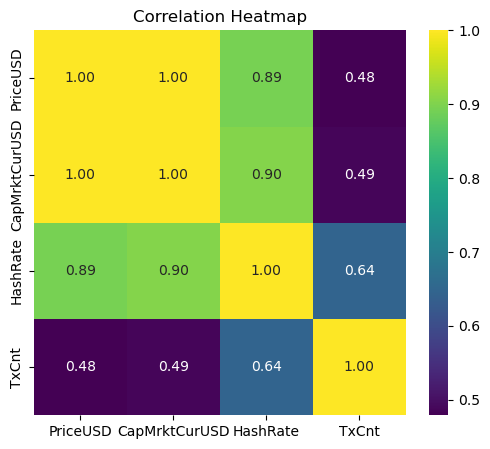

In [17]:
#Correlation Heatmap
correlation_cols = ["PriceUSD", "CapMrktCurUSD", "HashRate", "TxCnt"]
corr_df = df[correlation_cols].apply(pd.to_numeric, errors="coerce")

# corr
corr = corr_df.corr()

# heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

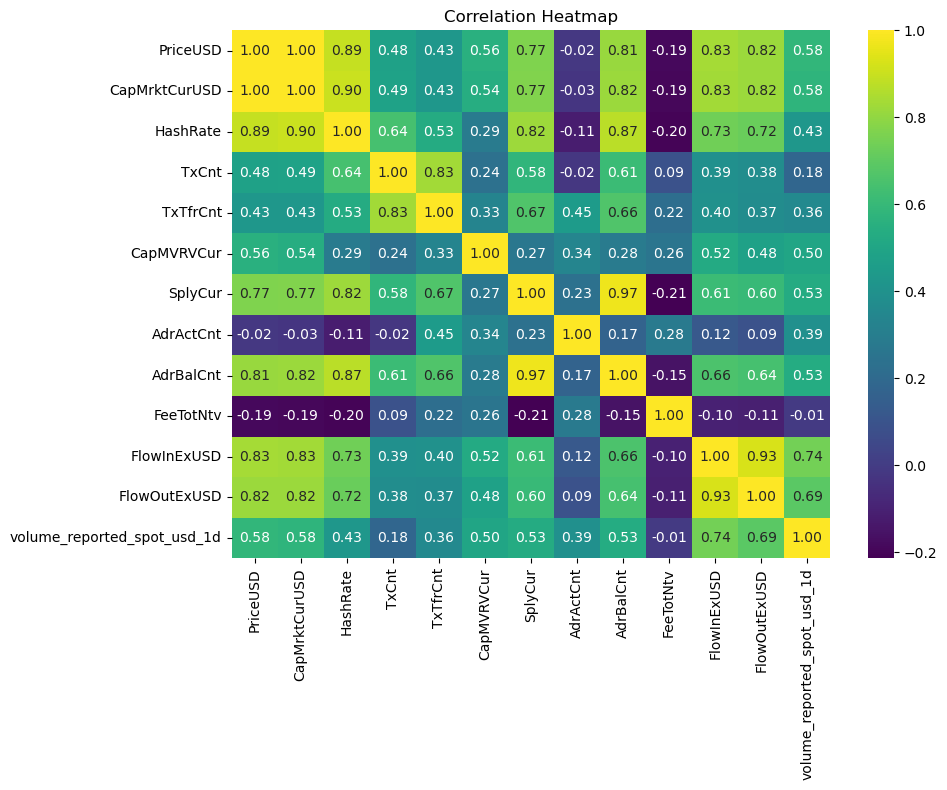

In [18]:
corr_cols = [
    "PriceUSD", "CapMrktCurUSD", "HashRate", "TxCnt", "TxTfrCnt",
    "CapMVRVCur", "SplyCur", "AdrActCnt", "AdrBalCnt",
    "FeeTotNtv", "FlowInExUSD", "FlowOutExUSD",
    "volume_reported_spot_usd_1d"
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [19]:
# Build accumulation common metrics
# net inflow >0 means net outflow ，<0 means net inflow
df["net_flow_usd"] = df["FlowOutExUSD"] - df["FlowInExUSD"]

# PnL in next 30 days
h = 30
df["fwd_ret_30d"] = df["PriceUSD"].shift(-h) / df["PriceUSD"] - 1

# Forward vol in 30D log return
logret = np.log(df["PriceUSD"]).diff()
df["fwd_vol_30d"] = logret.shift(-1).rolling(h).std() * np.sqrt(365)

# Max Drawdown in next 30D
# Make the lowest price in the forward window, then convert to max drawdown
future_min_price = df["PriceUSD"].shift(-1).rolling(h).min()
df["fwd_min_dd_30d"] = future_min_price / df["PriceUSD"] - 1 

# Remove missing data in the last 30D
eda = df.dropna(subset=["fwd_ret_30d", "fwd_vol_30d", "fwd_min_dd_30d"]).copy()



===  MVRV（CapMVRVCur）5 Buckets Grouping Result ===
  mvrv_q5    n  avg_fwd_ret_30d  med_fwd_ret_30d  avg_fwd_vol_30d  \
0       1  573         0.075359         0.054146         0.670342   
1       2  572         0.020615         0.000193         0.527412   
2       3  573         0.030614         0.012754         0.654079   
3       4  572         0.045156         0.012082         0.562571   
4       5  573         0.043455        -0.008083         0.601273   

   prob_dd_lt_20pct  prob_dd_lt_30pct  
0          0.136126          0.001745  
1          0.092657          0.008741  
2          0.211169          0.050611  
3          0.164336          0.050699  
4          0.392670          0.184991  


C:\Users\quant\AppData\Local\Temp\ipykernel_34844\2938279399.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mvrv_table = eda.groupby("mvrv_q5").agg(


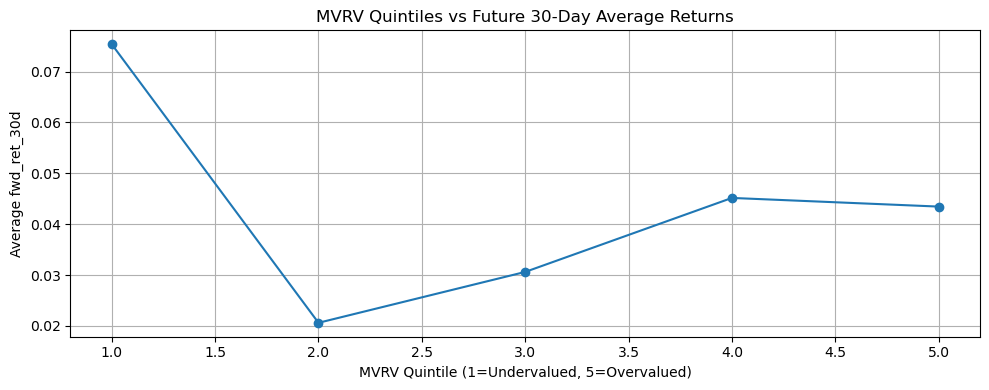

In [20]:
#One dimensional bin analysis 
#Group into 5 binnings by MVRV
eda["mvrv_q5"] = pd.qcut(eda["CapMVRVCur"], 5, labels=[1,2,3,4,5])
mvrv_table = eda.groupby("mvrv_q5").agg(
    n=("PriceUSD", "size"),
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    med_fwd_ret_30d=("fwd_ret_30d", "median"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
    prob_dd_lt_30pct=("fwd_min_dd_30d", lambda x: (x < -0.30).mean()),
).reset_index()

print("\n===  MVRV（CapMVRVCur）5 Buckets Grouping Result ===")
print(mvrv_table)

plt.figure(figsize=(10,4))
plt.plot(mvrv_table["mvrv_q5"], mvrv_table["avg_fwd_ret_30d"], marker="o")
plt.title("MVRV Quintiles vs Future 30-Day Average Returns")
plt.xlabel("MVRV Quintile (1=Undervalued, 5=Overvalued)")
plt.ylabel("Average fwd_ret_30d")
plt.grid(True)
plt.tight_layout()
plt.show()


=== Net Flow (net_flow_usd) Quintile Binning Results ===
  netflow_q5    n  avg_fwd_ret_30d  med_fwd_ret_30d  avg_fwd_vol_30d  \
0          1  573         0.019433        -0.014197         0.624681   
1          2  572         0.044643         0.022561         0.616223   
2          3  573         0.052355         0.025048         0.620103   
3          4  572         0.061835         0.027716         0.610376   
4          5  573         0.037003         0.007718         0.544532   

   prob_dd_lt_20pct  prob_dd_lt_30pct  
0          0.226876          0.099476  
1          0.187063          0.052448  
2          0.202443          0.043630  
3          0.201049          0.043706  
4          0.179756          0.057592  


C:\Users\quant\AppData\Local\Temp\ipykernel_34844\1815274353.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  netflow_table = eda.groupby("netflow_q5").agg(


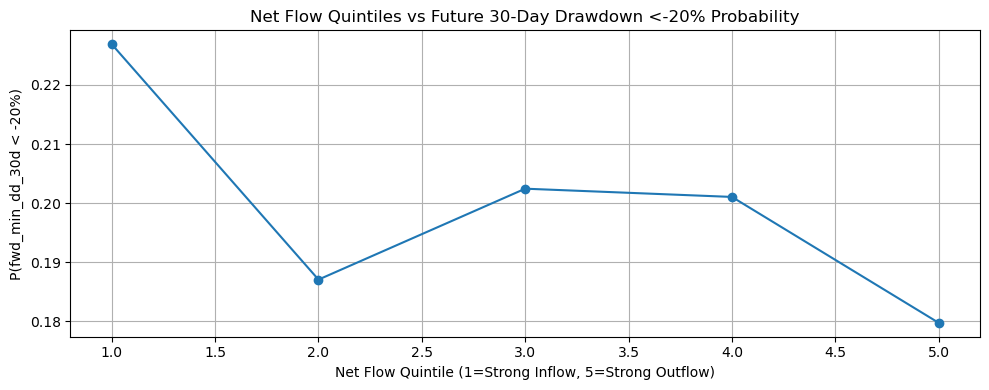

In [21]:
# Based on net_flow_usd group into 5
eda["netflow_q5"] = pd.qcut(eda["net_flow_usd"], 5, labels=[1,2,3,4,5])
netflow_table = eda.groupby("netflow_q5").agg(
    n=("PriceUSD", "size"),
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    med_fwd_ret_30d=("fwd_ret_30d", "median"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
    prob_dd_lt_30pct=("fwd_min_dd_30d", lambda x: (x < -0.30).mean()),
).reset_index()

print("\n=== Net Flow (net_flow_usd) Quintile Binning Results ===")
print(netflow_table)

plt.figure(figsize=(10,4))
plt.plot(netflow_table["netflow_q5"], netflow_table["prob_dd_lt_20pct"], marker="o")
plt.title("Net Flow Quintiles vs Future 30-Day Drawdown <-20% Probability")
plt.xlabel("Net Flow Quintile (1=Strong Inflow, 5=Strong Outflow)")
plt.ylabel("P(fwd_min_dd_30d < -20%)")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\quant\AppData\Local\Temp\ipykernel_34844\302040175.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adr_table = eda.groupby("adract_q5").agg(



=== （AdrActCnt）Quintile Binning Results ===
  adract_q5    n  avg_fwd_ret_30d  med_fwd_ret_30d  avg_fwd_vol_30d  \
0         1  573         0.017177        -0.002325         0.630627   
1         2  572         0.021092         0.001985         0.569494   
2         3  573         0.059636         0.023675         0.613425   
3         4  572         0.042854         0.012553         0.584313   
4         5  573         0.074436         0.038444         0.617930   

   prob_dd_lt_20pct  prob_dd_lt_30pct  
0          0.101222          0.008726  
1          0.125874          0.045455  
2          0.211169          0.057592  
3          0.230769          0.055944  
4          0.328098          0.129145  


C:\Users\quant\AppData\Local\Temp\ipykernel_34844\302040175.py:21: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\quant\AppData\Local\Temp\ipykernel_34844\302040175.py:21: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\quant\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\quant\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


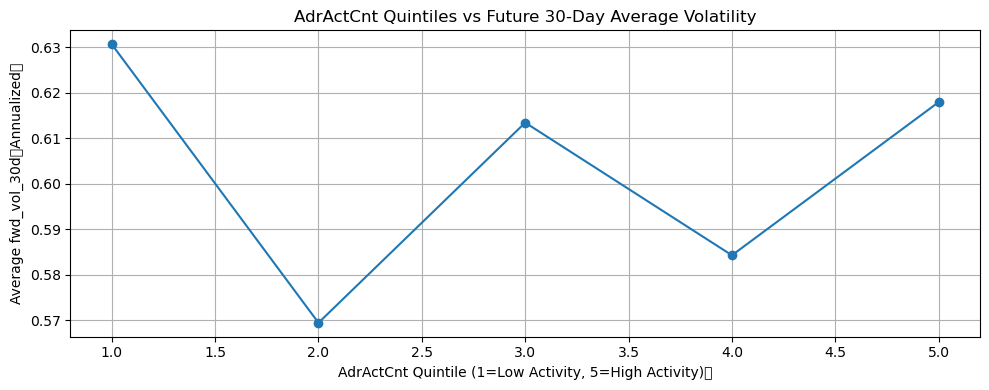

In [22]:
#  AdrActCnt 5 binning
eda["adract_q5"] = pd.qcut(eda["AdrActCnt"], 5, labels=[1,2,3,4,5])
adr_table = eda.groupby("adract_q5").agg(
    n=("PriceUSD", "size"),
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    med_fwd_ret_30d=("fwd_ret_30d", "median"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
    prob_dd_lt_30pct=("fwd_min_dd_30d", lambda x: (x < -0.30).mean()),
).reset_index()

print("\n=== （AdrActCnt）Quintile Binning Results ===")
print(adr_table)

plt.figure(figsize=(10,4))
plt.plot(adr_table["adract_q5"], adr_table["avg_fwd_vol_30d"], marker="o")
plt.title("AdrActCnt Quintiles vs Future 30-Day Average Volatility")
plt.xlabel("AdrActCnt Quintile (1=Low Activity, 5=High Activity)）")
plt.ylabel("Average fwd_vol_30d（Annualized）")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\quant\AppData\Local\Temp\ipykernel_34844\1703147531.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = eda.pivot_table(


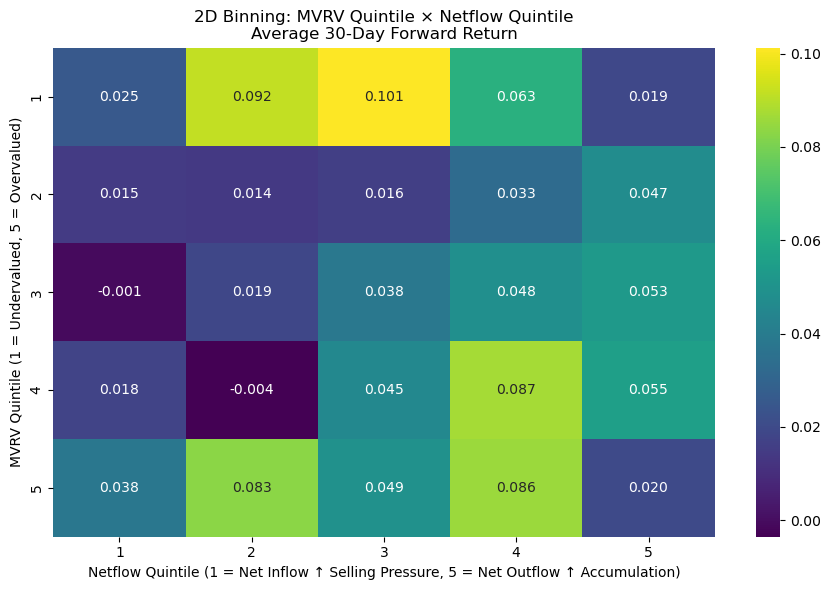

In [23]:
# 2D Binning: MVRV × Netflow
pivot = eda.pivot_table(
    index="mvrv_q5",
    columns="netflow_q5",
    values="fwd_ret_30d",
    aggfunc="mean"
)

plt.figure(figsize=(9,6))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")

plt.title("2D Binning: MVRV Quintile × Netflow Quintile\nAverage 30-Day Forward Return")
plt.xlabel("Netflow Quintile (1 = Net Inflow ↑ Selling Pressure, 5 = Net Outflow ↑ Accumulation)")
plt.ylabel("MVRV Quintile (1 = Undervalued, 5 = Overvalued)")

plt.tight_layout()
plt.show()

# 3. Polymarket data loading

In [24]:
#read polymarket data
import sys
import os
import polars as pl
#from pathlib import path

sys.path.append(os.path.abspath('..'))
# Import the loader from the template provided by the project
from eda_starter_template import load_polymarket_data, POLYMARKET_DIR

# Load the dictionary of DataFrames
poly_data_dict = load_polymarket_data(POLYMARKET_DIR)

# Extract individual DataFrames for easier use
if poly_data_dict:
    df_markets = poly_data_dict.get("markets")
    df_odds = poly_data_dict.get("odds")
    df_summary = poly_data_dict.get("summary")
    
    print("Data loaded successfully!")
else:
    print("Data directory not found. Check if the 'data/Polymarket' folder exists.")

Loading Polymarket data from C:\Users\quant\Trilemma\bitcoin-analytics-capstone-sp26-team08\data\Polymarket...
[Memory] Before loading Polymarket data: 258.26 MB
Loaded 78321 markets.
Loaded 2143181 odds history records.
Loaded 78321 summary records.
[Memory] After loading Polymarket data: 461.30 MB (Δ 203.04 MB)
Data loaded successfully!


In [25]:
df_markets.head()

market_id,question,slug,event_slug,category,volume,active,closed,created_at,end_date
str,str,str,str,str,f64,bool,bool,datetime[μs],datetime[μs]
"""242851""","""Will Bongbong Marcos be electe…","""will-bongbong-marcos-be-electe…","""will-bongbong-marcos-be-electe…","""Global Politics""",21533.53,true,true,2022-04-05 20:37:30,2022-05-09 00:00:00
"""242873""","""Will Sarah Palin win Alaska's …","""will-sarah-palin-win-in-the-al…","""will-sarah-palin-win-in-the-al…","""US-current-affairs""",79783.23,true,true,2022-04-05 22:41:57,2022-08-16 00:00:00
"""242918""","""Will US student loan payments …","""will-us-student-loan-payments-…","""will-us-student-loan-payments-…","""US-current-affairs""",18946.72,true,true,2022-04-05 23:33:47,2022-11-08 00:00:00
"""243183""","""Will $ETH be above $3,000 on A…","""will-eth-be-above-3000-on-apri…","""will-eth-be-above-3000-on-apri…","""Crypto""",974114.26,true,true,2022-04-12 16:51:10,2022-04-20 00:00:00
"""243192""","""Will Brian Kemp win the Republ…","""will-brian-kemp-win-the-republ…","""who-will-win-the-republican-no…","""US-current-affairs""",7024.92,true,true,2022-04-13 01:40:25,2022-05-24 00:00:00


In [26]:
tokens_path = POLYMARKET_DIR / "finance_politics_tokens.parquet"
event_path = POLYMARKET_DIR / "finance_politics_event_stats.parquet"
trades_path = POLYMARKET_DIR / "finance_politics_trades.parquet"

df_tokens = (
    pl.scan_parquet(tokens_path)
    .collect()
)
df_event = (
    pl.scan_parquet(event_path)
    .collect()
)

if trades_path.exists():
    trades_df = pl.scan_parquet(trades_path).collect()
    
    # Fix timestamp corruption
    for col in trades_df.columns:
        if any(x in col.lower() for x in ["timestamp", "trade", "created_at", "end_date"]):
            if trades_df[col].dtype == pl.Datetime or trades_df[col].dtype == pl.Date:
                if not trades_df[col].is_empty() and trades_df[col].max() < datetime(2020, 1, 1):
                    trades_df = trades_df.with_columns((pl.col(col).cast(pl.Int64) * 1000).cast(pl.Datetime))
                    
            # Enforce 2020+ constraint (replace placeholders/zeros with null)
            if trades_df[col].dtype == pl.Datetime or trades_df[col].dtype == pl.Date:
                    trades_df = trades_df.with_columns(
                        pl.when(pl.col(col) < datetime(2020, 1, 1))
                        .then(None)
                        .otherwise(pl.col(col))
                        .alias(col)
                    )
                
    print(f"Loaded {len(trades_df)} trades records.")

Loaded 27013724 trades records.


In [27]:
df_markets
# Filter for rows where both are True
both_true = df_markets.filter(
    (pl.col("active") == True) & (pl.col("closed") == True)
)

print(f"Total Markets: {len(df_markets)}")
print(f"Markets with (active=True AND closed=True): {len(both_true)}")

Total Markets: 78321
Markets with (active=True AND closed=True): 73200


# 3.1 Markets

In [28]:
df_markets.head()

#find unique category
df_markets['category'].unique()
search_list = ["bitcoin", "btc","crypto","blockchain",'ETH']
# filter crypto related event, and general political event
crypto_markets = df_markets.filter(
    (pl.col("category").is_in([ "Crypto", "Business",'Politics'])) |
    (pl.col("question").str.contains_any(search_list, ascii_case_insensitive=True))
)

crypto_markets['category'].unique()

#check aggregated newly created daily market
daily_pm_features = (
    crypto_markets
    .filter(pl.col("created_at").is_not_null())
    .group_by(pl.col("created_at").dt.date().alias("date"))
    .agg([
        pl.count("market_id").alias("pm_new_market_count"),
        pl.col("volume").sum().alias("pm_daily_volume"),
        # average days the market remain active
        ((pl.col("end_date") - pl.col("created_at")).dt.total_days()).mean().alias("avg_market_duration")
    ])
    .sort("date")
)

# Convert to pandas 
pm_features_pd = daily_pm_features.to_pandas()
pm_features_pd['date'] = pd.to_datetime(pm_features_pd['date'])

# 

Correlation between BTC and Polymarket Activity:
                     PriceUSD   vol_30d  pm_new_market_count  pm_daily_volume
PriceUSD             1.000000 -0.538750             0.526379         0.449619
vol_30d             -0.538750  1.000000            -0.356751        -0.250236
pm_new_market_count  0.526379 -0.356751             1.000000         0.470874
pm_daily_volume      0.449619 -0.250236             0.470874         1.000000


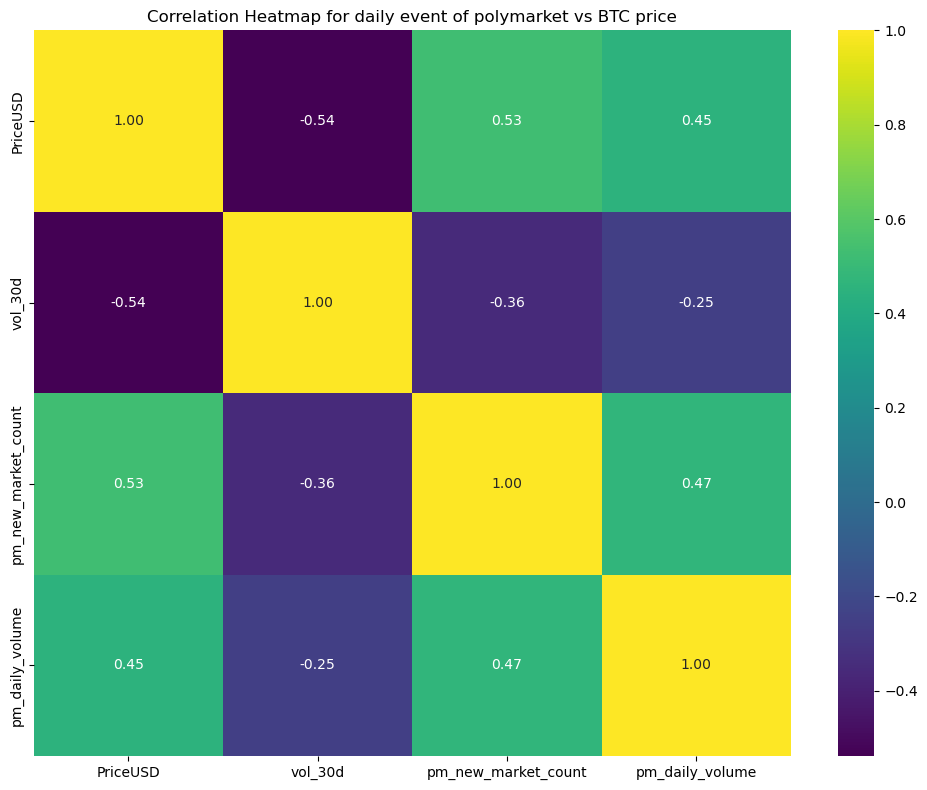

In [29]:
# combine markets with btc price data
btc_daily = eda.reset_index().rename(columns={'time':'date'})
btc_daily['date'] = btc_daily['date'].dt.normalize()

#merge the daily aggregated polymarket features with BTC price and vol
merged_markets_btc = btc_daily.merge(pm_features_pd,on='date',how='inner')

#correlation matrix
cols_to_corr = ['PriceUSD', 'vol_30d', 'pm_new_market_count', 'pm_daily_volume']
print("Correlation between BTC and Polymarket Activity:")
corr = merged_markets_btc[cols_to_corr].corr()
print(corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap for daily event of polymarket vs BTC price")
plt.tight_layout()
plt.show()

In [30]:
#investigate any lead lag relationship
merged_markets_btc['pm_count_lag1'] = merged_markets_btc['pm_new_market_count'].shift(1)

# Calculate correlation with Price Change (Returns) instead of absolute Price
merged_markets_btc['ret_1d'] = merged_markets_btc['PriceUSD'].pct_change()

lead_corr = merged_markets_btc[['ret_1d', 'pm_count_lag1']].corr()
print("Whether yesterday's PM activity predict today's BTC return?")
print(lead_corr)

Whether yesterday's PM activity predict today's BTC return?
                 ret_1d  pm_count_lag1
ret_1d         1.000000      -0.053154
pm_count_lag1 -0.053154       1.000000


Top 10 Macro Event Clusters by Volume:
shape: (10, 6)
┌─────────────────┬─────────────────┬─────────────────┬──────────┬────────────────┬────────────────┐
│ event_slug      ┆ total_event_vol ┆ sub_market_coun ┆ %_active ┆ start_date     ┆ end_date       │
│ ---             ┆ ume             ┆ t               ┆ ---      ┆ ---            ┆ ---            │
│ str             ┆ ---             ┆ ---             ┆ f64      ┆ datetime[μs]   ┆ datetime[μs]   │
│                 ┆ f64             ┆ u32             ┆          ┆                ┆                │
╞═════════════════╪═════════════════╪═════════════════╪══════════╪════════════════╪════════════════╡
│ presidential-el ┆ 3.6863e9        ┆ 17              ┆ 1.0      ┆ 2024-01-04     ┆ 2024-11-05     │
│ ection-winner-2 ┆                 ┆                 ┆          ┆ 17:33:51       ┆ 12:00:00       │
│ …               ┆                 ┆                 ┆          ┆                ┆                │
│ presidential-el ┆ 6.2816e8        ┆

C:\Users\quant\AppData\Local\Temp\ipykernel_34844\706763173.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=event_clusters.to_pandas(), x="total_event_volume", y="event_slug", palette="viridis")


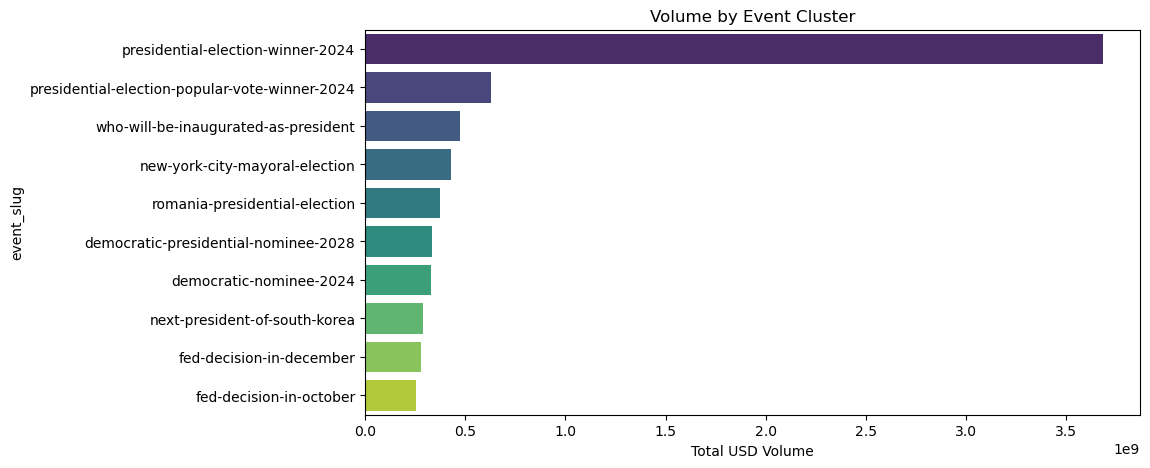

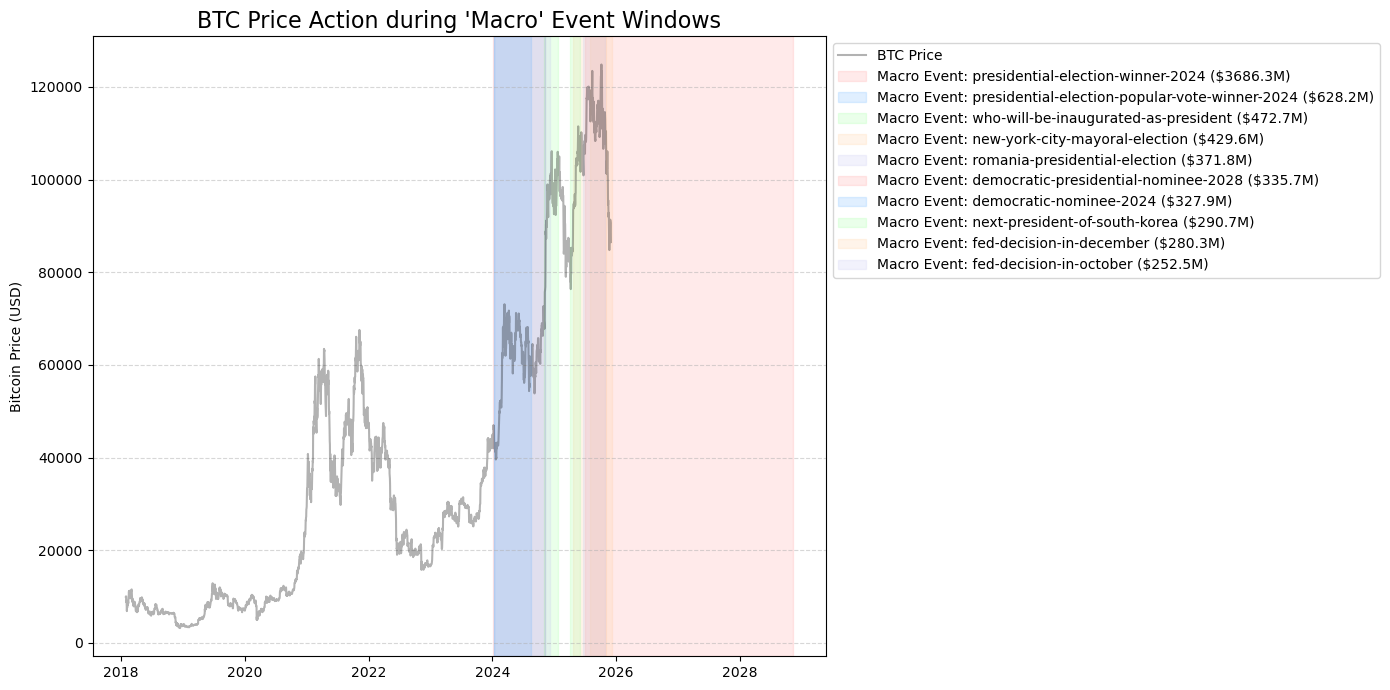

In [31]:
# Check event slug level
#1 event cluster shows election tops the chart (as expected)
event_clusters = (
    df_markets
    .group_by("event_slug")
    .agg([
        pl.col("volume").sum().alias("total_event_volume"),
        pl.count("market_id").alias("sub_market_count"),
        pl.col("active").mean().alias("%_active"),
        pl.col("created_at").min().alias("start_date"),
        pl.col("end_date").max().alias("end_date")
    ])
    .sort("total_event_volume", descending=True)
    .head(10) 
)

print("Top 10 Macro Event Clusters by Volume:")
print(event_clusters)

# Visualization of Event Clusters
plt.figure(figsize=(10, 5))
sns.barplot(data=event_clusters.to_pandas(), x="total_event_volume", y="event_slug", palette="viridis")
plt.title("Volume by Event Cluster")
plt.xlabel("Total USD Volume")
plt.show()

#2 plot BTC price
plt.figure(figsize=(14, 7))

# Plot BTC Price
plt.plot(btc_daily['date'], btc_daily['PriceUSD'], color='black', alpha=0.3, label='BTC Price')
plt.ylabel("Bitcoin Price (USD)")

#3 overlay the cluster, check btc movement during big macro event
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']

for i, row in enumerate(event_clusters.to_dicts()):
    # Convert to pandas timestamps for plotting
    start = pd.to_datetime(row['start_date'])
    end = pd.to_datetime(row['end_date'])
    
    # Shade the area where this Macro event was active
    plt.axvspan(start, end, alpha=0.2, color=colors[i % len(colors)], 
                label=f"Macro Event: {row['event_slug']} (${row['total_event_volume']/1e6:.1f}M)")

plt.title("BTC Price Action during 'Macro' Event Windows", fontsize=16)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

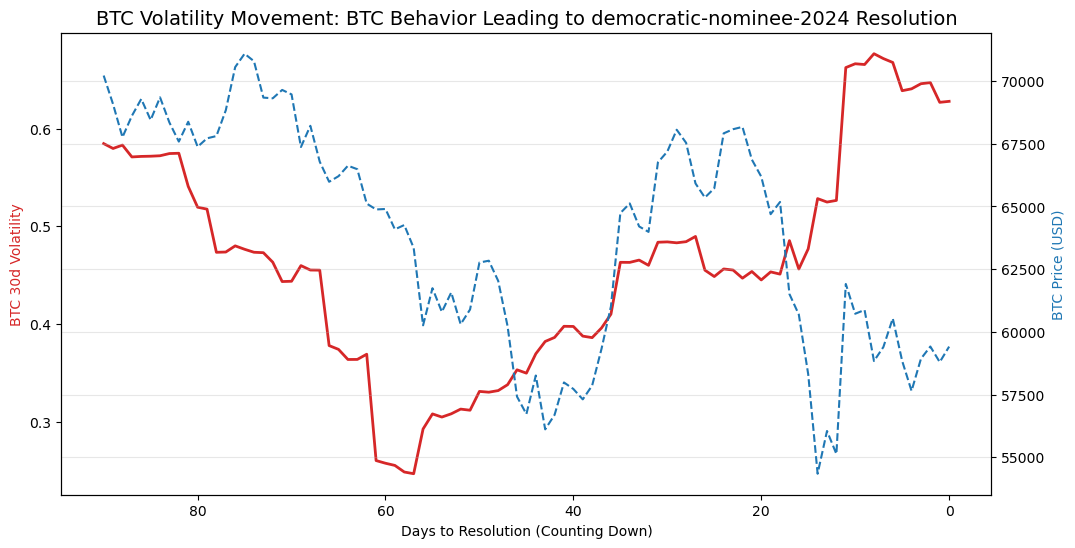

In [32]:
#Check volatility change when event approaches the end

major_slug = event_clusters['event_slug'][6] 

magnet_markets = df_markets.filter(pl.col("event_slug") == major_slug)

# 2. Calculate "Days to Resolution" for each day in history
# We join the BTC daily dates with the event's end date
resolution_date = magnet_markets['end_date'].max()

btc_pressure = btc_daily.copy()
btc_pressure['days_to_res'] = (pd.to_datetime(resolution_date) - pd.to_datetime(btc_pressure['date'])).dt.days

# Filter to only show the 90 days leading up to the resolution
btc_pressure = btc_pressure[(btc_pressure['days_to_res'] >= 0) & (btc_pressure['days_to_res'] <= 90)]

# 3. Plot Volatility vs Countdown
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Days to Resolution (Counting Down)')
ax1.set_ylabel('BTC 30d Volatility', color='tab:red')
ax1.plot(btc_pressure['days_to_res'], btc_pressure['vol_30d'], color='tab:red', linewidth=2)
ax1.invert_xaxis() # Countdown from 90 to 0

ax2 = ax1.twinx()
ax2.set_ylabel('BTC Price (USD)', color='tab:blue')
ax2.plot(btc_pressure['days_to_res'], btc_pressure['PriceUSD'], color='tab:blue', linestyle='--')

plt.title(f"BTC Volatility Movement: BTC Behavior Leading to {major_slug} Resolution", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# 3.2 Tokens

In [33]:
df_tokens

market_id,token_id,outcome
str,str,str
"""240383""","""555875344331027638590324435858…","""Yes"""
"""240383""","""111837615529992437689409005124…","""No"""
"""240384""","""113459643164060403919504712048…","""Yes"""
"""240384""","""110606609354376812966157988257…","""No"""
"""240385""","""505435736314143687770680977181…","""Yes"""
…,…,…
"""892920""","""496224936867145107714728324950…","""Down"""
"""892921""","""116918525891988714423444796180…","""Up"""
"""892921""","""827298723842613390623635576167…","""Down"""


In [34]:
df_tokens.select("outcome").unique()

outcome
str
"""$2200"""
"""Weil"""
"""Harris """
"""Zelenskyy"""
"""Salas"""
…
"""Over 2%"""
"""Missouri Tigers"""
"""$3000"""


# 3.4 Odds History

In [35]:
df_odds = df_odds.with_columns(
    pl.col("timestamp").dt.date().alias("date")
)

df_odds.head()

market_id,token_id,timestamp,price,date
str,str,datetime[μs],f64,date
"""255140""","""474357953615233060686693901910…",2024-06-08 00:00:02,0.055,2024-06-08
"""255140""","""474357953615233060686693901910…",2024-06-09 00:00:03,0.055,2024-06-09
"""255140""","""474357953615233060686693901910…",2024-06-10 00:00:04,0.055,2024-06-10
"""255140""","""474357953615233060686693901910…",2024-06-11 00:00:02,0.055,2024-06-11
"""255140""","""474357953615233060686693901910…",2024-06-12 00:00:03,0.055,2024-06-12


In [36]:
df_tokens_simple = (
    df_tokens
    .with_columns(pl.col("outcome").str.to_lowercase().alias("outcome_lower"))
    .filter(
        pl.col("outcome_lower").is_in(["yes", "no", "up", "down"])
    )
)

In [37]:
df_odds_simple = df_odds.join(
    df_tokens_simple.select(["market_id", "token_id", "outcome"]),
    on=["market_id", "token_id"],
    how="inner"
)

df_odds_simple.head()

market_id,token_id,timestamp,price,date,outcome
str,str,datetime[μs],f64,date,str
"""255140""","""474357953615233060686693901910…",2024-06-08 00:00:02,0.055,2024-06-08,"""Yes"""
"""255140""","""474357953615233060686693901910…",2024-06-09 00:00:03,0.055,2024-06-09,"""Yes"""
"""255140""","""474357953615233060686693901910…",2024-06-10 00:00:04,0.055,2024-06-10,"""Yes"""
"""255140""","""474357953615233060686693901910…",2024-06-11 00:00:02,0.055,2024-06-11,"""Yes"""
"""255140""","""474357953615233060686693901910…",2024-06-12 00:00:03,0.055,2024-06-12,"""Yes"""


In [38]:
df_daily = (
    df_odds_simple
    .sort(["market_id", "date", "timestamp"])
    .group_by(["market_id", "date"])
    .agg([
        pl.col("price").last().alias("p_close"),
        pl.count().alias("update_count")
    ])
    .sort(["market_id", "date"])
)

df_daily = df_daily.with_columns(
    (pl.col("p_close") - pl.col("p_close").shift(1))
    .over("market_id")
    .alias("p_diff_1d")
)

df_daily = df_daily.with_columns(
    pl.col("p_diff_1d")
    .rolling_std(7)
    .over("market_id")
    .alias("p_vol_7d")
)

C:\Users\quant\AppData\Local\Temp\ipykernel_34844\84762546.py:7: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("update_count")


In [39]:
df_daily.describe()

statistic,market_id,date,p_close,update_count,p_diff_1d,p_vol_7d
str,str,str,f64,f64,f64,f64
"""count""","""785733""","""785733""",785733.0,785733.0,728826.0,574131.0
"""null_count""","""0""","""0""",0.0,0.0,56907.0,211602.0
"""mean""",null,"""2025-05-03 11:34:47.211304""",0.506068,2.711594,0.000217,0.398543
"""std""",null,null,0.397924,5.15958,0.446207,0.281002
"""min""","""248385""","""2023-01-24""",0.0005,1.0,-0.999,0.0
"""25%""",null,"""2024-11-23""",0.065,2.0,-0.0075,0.098125
"""50%""",null,"""2025-07-21""",0.5,2.0,0.0,0.414486
"""75%""",null,"""2025-10-29""",0.9425,2.0,0.008,0.624219
"""max""","""905434""","""2026-01-05""",1.0,50.0,0.999,1.067976


In [40]:
daily_index = (
    df_daily
    .group_by("date")
    .agg([
        pl.col("p_vol_7d").mean().alias("risk_index"),
        pl.col("p_diff_1d").mean().alias("prob_shift_index"),
        pl.col("update_count").mean().alias("attention_index"),
        pl.count().alias("num_markets")
    ])
    .sort("date")
)

C:\Users\quant\AppData\Local\Temp\ipykernel_34844\1281110981.py:8: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("num_markets")


In [41]:
daily_pd = pd.DataFrame(daily_index.to_dict(as_series=False))

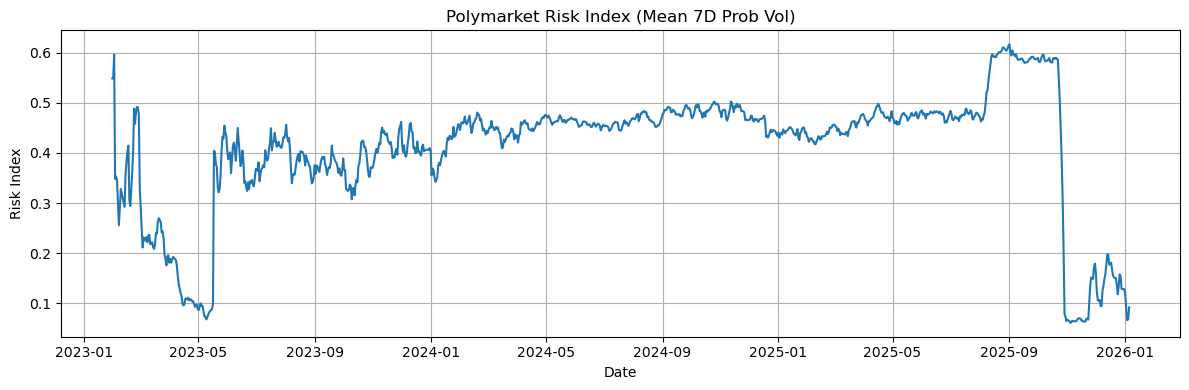

In [42]:
plt.figure(figsize=(12,4))
plt.plot(daily_pd["date"], daily_pd["risk_index"])
plt.title("Polymarket Risk Index (Mean 7D Prob Vol)")
plt.xlabel("Date")
plt.ylabel("Risk Index")
plt.grid(True)
plt.tight_layout()
plt.show()

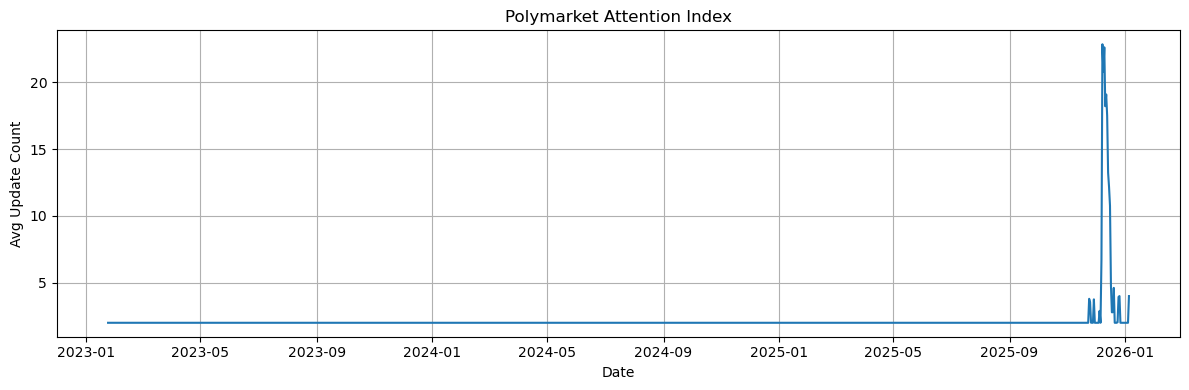

In [43]:
plt.figure(figsize=(12,4))
plt.plot(daily_pd["date"], daily_pd["attention_index"])
plt.title("Polymarket Attention Index")
plt.xlabel("Date")
plt.ylabel("Avg Update Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
btc_pd = df.reset_index()[["time", "PriceUSD"]]
daily_pd["date"] = pd.to_datetime(daily_pd["date"]).dt.normalize()
btc_pd["time"] = pd.to_datetime(btc_pd["time"]).dt.normalize()

merged = daily_pd.merge(
    btc_pd,
    left_on="date",
    right_on="time",
    how="inner"
)

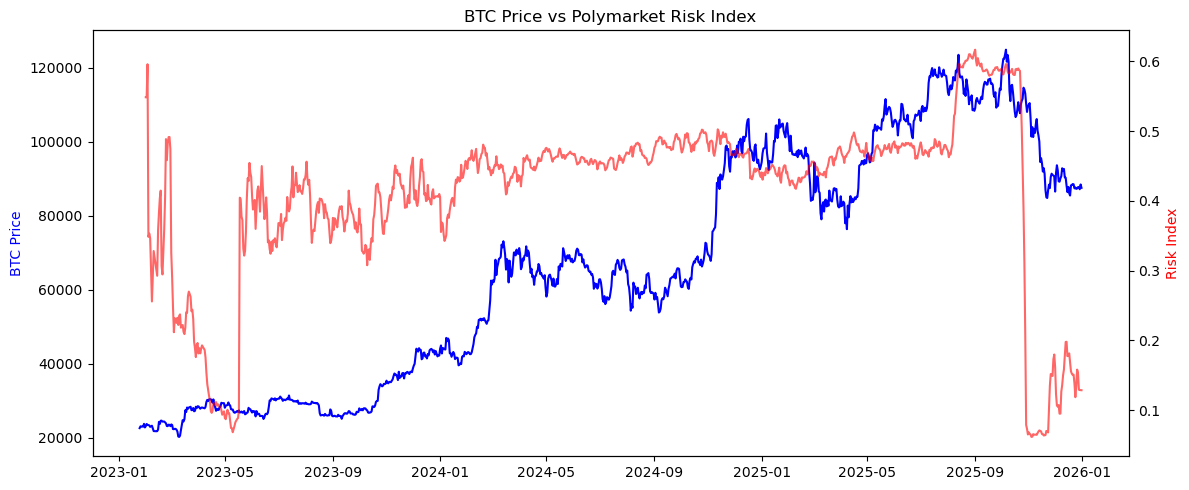

In [45]:
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(merged["date"], merged["PriceUSD"], color="blue")
ax1.set_ylabel("BTC Price", color="blue")

ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["risk_index"], color="red", alpha=0.6)
ax2.set_ylabel("Risk Index", color="red")

plt.title("BTC Price vs Polymarket Risk Index")
plt.tight_layout()
plt.show()

In [46]:
#分箱分析
merged["risk_q5"] = pd.qcut(merged["risk_index"], 5, labels=[1,2,3,4,5])

risk_table = merged.groupby("risk_q5").agg(
    avg_btc_price=("PriceUSD","mean")
)

print(risk_table)

         avg_btc_price
risk_q5               
1         48669.632586
2         42693.592849
3         70812.645333
4         81598.494807
5         92421.121215


C:\Users\quant\AppData\Local\Temp\ipykernel_34844\492445336.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_table = merged.groupby("risk_q5").agg(


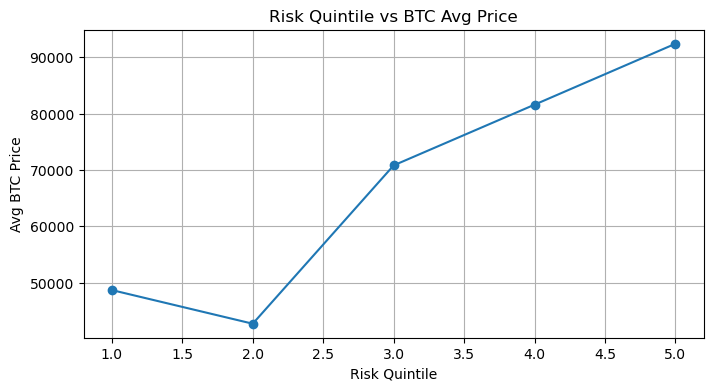

In [47]:
plt.figure(figsize=(8,4))
plt.plot(risk_table.index, risk_table["avg_btc_price"], marker="o")
plt.title("Risk Quintile vs BTC Avg Price")
plt.xlabel("Risk Quintile")
plt.ylabel("Avg BTC Price")
plt.grid(True)
plt.show()

# 3.5 Trades

In [48]:
trades_df.head()

trade_id,market_id,token_id,timestamp,price,size,side,maker_address,taker_address
str,str,str,datetime[μs],f64,f64,str,str,str
"""0x036e539d9361b15d9ebee9bbd1ae…","""570360""","""214897725164100385865567443423…",2025-11-19 13:44:05,0.977,281.054246,"""BUY""","""0x27d76669db4321111b08fcc7e1a5…","""0xc5d563a36ae78145c45a50134d48…"
"""0x8685bb4a3134f9f664ed7e619b8e…","""570360""","""214897725164100385865567443423…",2025-11-19 13:44:17,0.977,28.0,"""BUY""","""0x33dcee9b336230ed7460c98bec8f…","""0xc5d563a36ae78145c45a50134d48…"
"""0xab71cfe8f3cb18e629b873b65b84…","""570360""","""214897725164100385865567443423…",2025-11-19 13:44:31,0.977,182.0,"""BUY""","""0x87370aa54b8f70fa1c9637f367aa…","""0xc5d563a36ae78145c45a50134d48…"
"""0xfe619b29a0b6aa958cbd565c18f0…","""570360""","""214897725164100385865567443423…",2025-11-19 13:44:49,0.977081,49.0,"""BUY""","""0xa3ad70cf48a2f2b44163e798223c…","""0xc5d563a36ae78145c45a50134d48…"
"""0x953032bcaecd5bf0007c44acddb0…","""570360""","""214897725164100385865567443423…",2025-11-19 13:45:25,0.978,147.8,"""BUY""","""0x4ee06f42e20ee128db78d4225217…","""0xc5d563a36ae78145c45a50134d48…"


In [49]:
# Identify the top 15 traders by total volume (USD)
whales = (
    trades_df
    .with_columns((pl.col("price") * pl.col("size")).alias("usd_value"))
    .group_by("taker_address")
    .agg(pl.col("usd_value").sum().alias("total_spent"))
    .sort("total_spent", descending=True)
    .head(15)
)

print("Top Whales on Polymarket:")
print(whales)

Top Whales on Polymarket:
shape: (15, 2)
┌─────────────────────────────────┬─────────────┐
│ taker_address                   ┆ total_spent │
│ ---                             ┆ ---         │
│ str                             ┆ f64         │
╞═════════════════════════════════╪═════════════╡
│ 0xc5d563a36ae78145c45a50134d48… ┆ 6.7263e8    │
│ 0x4bfb41d5b3570defd03c39a9a4d8… ┆ 4.9879e8    │
│                                 ┆ 1.5007e8    │
│ 0xd218e474776403a330142299f779… ┆ 2.1735e7    │
│ 0x0540f430df85c770e0a4fb79d849… ┆ 1.3320e7    │
│ …                               ┆ …           │
│ 0x9155e8cf81a3fb557639d23d43f1… ┆ 4.7473e6    │
│ 0x8e9eedf20dfa70956d49f608a205… ┆ 4.1986e6    │
│ 0x63d43bbb87f85af03b8f2f9e2fad… ┆ 4.0525e6    │
│ 0x24c8cf69a0e0a17eee21f69d2975… ┆ 4.0287e6    │
│ 0xe34fa89ce3a484cb9543a6f11613… ┆ 4.0251e6    │
└─────────────────────────────────┴─────────────┘


In [50]:
# # Calculate buy pressure per hour

# buy_sell_pressure = (
#     trades_df
#     .sort("timestamp") 
#     .with_columns(
#         #BUY is positive, everything else (SELL) is negative
#         pl.when(pl.col("side") == "BUY").then(1).otherwise(-1).alias("direction")
#     )
#     .with_columns(
#         # USDvalue
#         (pl.col("direction") * pl.col("size") * pl.col("price")).alias("net_flow")
#     )
#     #Group into 1-hour buckets
#     .group_by_dynamic("timestamp", every="1h")
#     .agg([
#         # Aggregate the net_flow to get the actual "Buy Pressure"
#         pl.col("net_flow").sum().alias("hourly_net_buy_pressure"),
#         pl.col("size").sum().alias("hourly_volume"),
#         pl.count("trade_id").alias("trade_count")
#     ])
# )

# print(buy_sell_pressure.head())

In [ ]:
# Identify concentrated bets - certain address responsible for most volume of bets
address_concentration = (
    trades_df
    .group_by("taker_address")
    .agg(pl.count().alias("trade_count"))
    .sort("trade_count", descending=True)
)


C:\Users\quant\AppData\Local\Temp\ipykernel_34844\4206646795.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("trade_count"))


In [52]:
address_concentration.head(20)

taker_address,trade_count
str,u32
"""0x4bfb41d5b3570defd03c39a9a4d8…",8097122
"""0xc5d563a36ae78145c45a50134d48…",2337895
"""""",1800991
"""0xca85f4b9e472b542e1df039594ee…",929753
"""0x537494c54dee9162534675712f2e…",266541
…,…
"""0x5248313731287b61d714ab9df655…",119335
"""0x21504551452f4c4b67a1fbee6ba7…",105636
"""0x7485d661b858b117a66e1b4fcbec…",104553


In [ ]:
#Find big trades
bigtrade_threshold = 10000  # $10k+ single trade

big_bets = (
    trades_df
    .select(["market_id", "timestamp", "price", "size", "side"])
    .with_columns((pl.col("price") * pl.col("size")).alias("usd_value"))
    .filter(pl.col("usd_value") > bigtrade_threshold)
)
big_bets.head(20)


market_id,timestamp,price,size,side,usd_value
str,datetime[μs],f64,f64,str,f64
"""570360""",2025-11-19 17:43:09,0.979,40000.0,"""BUY""",39160.0
"""570360""",2025-11-19 17:53:53,0.981,40000.0,"""BUY""",39240.0
"""570360""",2025-11-19 18:32:19,0.981,43000.0,"""BUY""",42183.0
"""570360""",2025-11-19 18:57:49,0.98,17411.57,"""BUY""",17063.3386
"""570360""",2025-11-19 18:57:49,0.98,23008.0,"""BUY""",22547.84
…,…,…,…,…,…
"""570360""",2025-11-20 16:44:45,0.986,18497.36,"""BUY""",18238.39696
"""570360""",2025-11-20 19:13:11,0.986,11185.745713,"""BUY""",11029.145274
"""570360""",2025-11-20 19:13:11,0.986,22233.0,"""BUY""",21921.738


In [70]:
big_markets = big_bets.head(20).join(
    df_markets, 
    on="market_id", 
    how="inner"
)
big_markets.sort("usd_value", descending=True).head(10)



market_id,timestamp,price,size,side,usd_value,question,slug,event_slug,category,volume,active,closed,created_at,end_date
str,datetime[μs],f64,f64,str,f64,str,str,str,str,f64,bool,bool,datetime[μs],datetime[μs]
"""570360""",2025-11-20 15:11:13,0.986,125548.0,"""BUY""",123790.328,"""Fed decreases interest rates b…","""fed-decreases-interest-rates-b…","""fed-decision-in-december""","""""",9.8537e7,true,false,2025-07-31 19:28:08,2025-12-10 00:00:00
"""570360""",2025-11-20 21:35:11,0.987,100000.0,"""BUY""",98700.0,"""Fed decreases interest rates b…","""fed-decreases-interest-rates-b…","""fed-decision-in-december""","""""",9.8537e7,true,false,2025-07-31 19:28:08,2025-12-10 00:00:00
"""570360""",2025-11-20 13:17:33,0.984,49945.28,"""BUY""",49146.15552,"""Fed decreases interest rates b…","""fed-decreases-interest-rates-b…","""fed-decision-in-december""","""""",9.8537e7,true,false,2025-07-31 19:28:08,2025-12-10 00:00:00
"""570360""",2025-11-20 13:56:09,0.986,47234.37,"""BUY""",46573.08882,"""Fed decreases interest rates b…","""fed-decreases-interest-rates-b…","""fed-decision-in-december""","""""",9.8537e7,true,false,2025-07-31 19:28:08,2025-12-10 00:00:00
"""570360""",2025-11-19 18:32:19,0.981,43000.0,"""BUY""",42183.0,"""Fed decreases interest rates b…","""fed-decreases-interest-rates-b…","""fed-decision-in-december""","""""",9.8537e7,true,false,2025-07-31 19:28:08,2025-12-10 00:00:00
"""570360""",2025-11-19 17:53:53,0.981,40000.0,"""BUY""",39240.0,"""Fed decreases interest rates b…","""fed-decreases-interest-rates-b…","""fed-decision-in-december""","""""",9.8537e7,true,false,2025-07-31 19:28:08,2025-12-10 00:00:00
"""570360""",2025-11-19 17:43:09,0.979,40000.0,"""BUY""",39160.0,"""Fed decreases interest rates b…","""fed-decreases-interest-rates-b…","""fed-decision-in-december""","""""",9.8537e7,true,false,2025-07-31 19:28:08,2025-12-10 00:00:00
"""570360""",2025-11-19 18:57:49,0.98,23008.0,"""BUY""",22547.84,"""Fed decreases interest rates b…","""fed-decreases-interest-rates-b…","""fed-decision-in-december""","""""",9.8537e7,true,false,2025-07-31 19:28:08,2025-12-10 00:00:00
"""570360""",2025-11-20 19:13:11,0.986,22233.0,"""BUY""",21921.738,"""Fed decreases interest rates b…","""fed-decreases-interest-rates-b…","""fed-decision-in-december""","""""",9.8537e7,true,false,2025-07-31 19:28:08,2025-12-10 00:00:00
